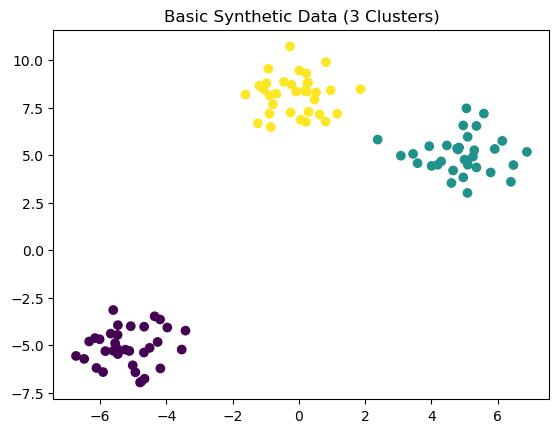

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Define cluster centers
centroids = [(-5, -5), (5, 5), (0, 8)]

# Generate data
X, y = make_blobs(
    n_samples=100,
    centers=centroids,
    cluster_std=1.0,
    n_features=2,
    random_state=42
)

# Visualize
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title("Basic Synthetic Data (3 Clusters)")
plt.show()

In [2]:
class KMeans:
    def __init__(self, n_clusters=3, max_iter=100):
        self.n_clusters = n_clusters   
        self.max_iter = max_iter
        self.centroids = None


In [3]:
# Choose k and start centroids

In [4]:
import numpy as np

class KMeans:
    def __init__(self, n_clusters=3, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def _initialize_centroids(self, X):
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

    def assign_clusters(self, X):
        cluster_group = []

        for row in X:
            distances = []
            for centroid in self.centroids:
                dist = np.sqrt(np.dot(row - centroid, row - centroid))
                distances.append(dist)

            index_pos = int(np.argmin(distances))
            cluster_group.append(index_pos)

        return np.array(cluster_group)

    def move_centroids(self, X, cluster_group):
        new_centroids = []

        for cluster_idx in range(self.n_clusters):
            cluster_points = X[cluster_group == cluster_idx]

            if len(cluster_points) == 0:
                new_centroids.append(self.centroids[cluster_idx])
            else:
                new_centroids.append(cluster_points.mean(axis=0))

        return np.array(new_centroids)

    def fit_predict(self, X):
        self._initialize_centroids(X)

        for _ in range(self.max_iter):
            cluster_group = self.assign_clusters(X)
            old_centroids = self.centroids.copy()
            self.centroids = self.move_centroids(X, cluster_group)

            if np.allclose(old_centroids, self.centroids):
                break

        return cluster_group

# K-Means Distance Calculation

In K-Means, each data point is assigned to the nearest centroid using Euclidean distance.

## Two Points

Let  
A = (x₁, y₁)  
B = (x₂, y₂)

## Distance Formula

$$
d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

Step-by-step:
- Subtract coordinates → $(x_2 - x_1), (y_2 - y_1)$  
- Square them  
- Add the squares  
- Take square root  

## Vector Form

$$
(x_2 - x_1,\; y_2 - y_1)
$$

Distance is the magnitude of this vector:

$$
\|B - A\| = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}
$$

## Higher Dimensions

$$
d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2 + (z_2 - z_1)^2 + \dots}
$$

## NumPy Implementation

```python
import numpy as np

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))
```

In [5]:
kmeans = KMeans(n_clusters=3, max_iter=100)
kmeans._initialize_centroids(X)

In [6]:
# Distances
dist_matrix = np.sqrt(((X[:, None, :] - kmeans.centroids[None, :, :]) ** 2).sum(axis=2))

print("Distance matrix shape:", dist_matrix.shape)
print("First 10 points distances to each centroid:")
for i, d in enumerate(dist_matrix[:10]):
    print(f"Point {i}: {d}")

Distance matrix shape: (100, 3)
First 10 points distances to each centroid:
Point 0: [14.36046306  0.54766052  4.1265973 ]
Point 1: [ 0.72361467 14.95623884 13.92750726]
Point 2: [13.14366728  4.48300512  0.38018804]
Point 3: [ 0.38141657 14.701038   13.59659417]
Point 4: [14.68416338  1.21614368  5.77921625]
Point 5: [ 1.31382193 15.24034034 13.62419366]
Point 6: [14.56666674  6.14985975  1.81386018]
Point 7: [14.24171755  0.86682661  5.2019769 ]
Point 8: [ 1.5830902  14.10700769 12.43966705]
Point 9: [ 1.36478015 15.99845755 14.81116126]


In [7]:
# Nearest centroid
min_centroid_idx = np.argmin(dist_matrix, axis=1)

print("Index of nearest centroid for first 10 points:")
for i, idx in enumerate(min_centroid_idx[:10]):
    print(f"Point {i} -> centroid index {idx}")

print("\nAll nearest-centroid indices:")
print(min_centroid_idx)

Index of nearest centroid for first 10 points:
Point 0 -> centroid index 1
Point 1 -> centroid index 0
Point 2 -> centroid index 2
Point 3 -> centroid index 0
Point 4 -> centroid index 1
Point 5 -> centroid index 0
Point 6 -> centroid index 2
Point 7 -> centroid index 1
Point 8 -> centroid index 0
Point 9 -> centroid index 0

All nearest-centroid indices:
[1 0 2 0 1 0 2 1 0 0 0 1 2 1 1 1 0 1 1 2 2 1 1 2 1 0 2 0 1 0 2 0 0 1 0 2 1
 0 1 1 1 2 2 0 1 1 2 0 1 0 2 2 1 1 2 1 2 1 0 1 2 2 1 1 1 0 2 1 2 1 2 2 0 2
 0 1 0 0 0 2 0 2 2 2 0 2 0 0 0 2 0 2 2 2 2 0 0 0 1 0]


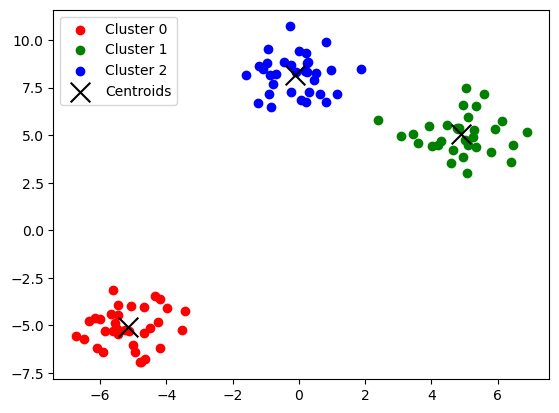

In [8]:
km = KMeans(n_clusters=3, max_iter=100)
y_means=km.fit_predict(X)
# Plot clusters
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], color="red", label="Cluster 0")
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], color="green", label="Cluster 1")
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], color="blue", label="Cluster 2")
plt.scatter(km.centroids[:, 0], km.centroids[:, 1], s=200, color="black", marker="x", label="Centroids")
plt.legend()
plt.show()


#### checking function on iris data

In [9]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

data = load_iris()
X_iris = data.data
y_true = data.target

iris_kmeans = KMeans(n_clusters=3, max_iter=100)
y_pred = iris_kmeans.fit_predict(X_iris)

cm = confusion_matrix(y_true, y_pred)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
y_aligned = np.array([mapping[label] for label in y_pred])

print("Confusion matrix:")
print(cm)
print("\nCluster-to-class mapping:", mapping)
print("accuracy:", accuracy_score(y_true, y_aligned))

Confusion matrix:
[[ 0  0 50]
 [ 2 48  0]
 [36 14  0]]

Cluster-to-class mapping: {np.int64(2): np.int64(0), np.int64(1): np.int64(1), np.int64(0): np.int64(2)}
accuracy: 0.8933333333333333


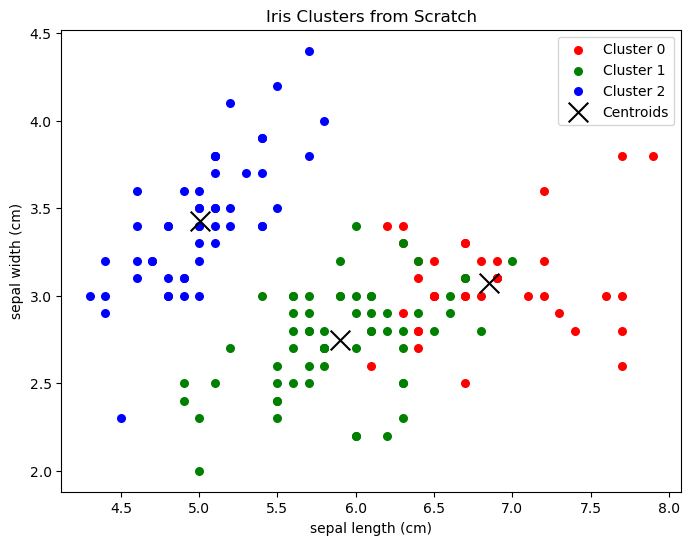

In [10]:
# Iris cluster plot
plt.figure(figsize=(8, 6))
colors = ["red", "green", "blue"]

for cluster_idx in range(3):
    mask = y_pred == cluster_idx
    plt.scatter(X_iris[mask, 0], X_iris[mask, 1], s=30, color=colors[cluster_idx], label=f"Cluster {cluster_idx}")

plt.scatter(iris_kmeans.centroids[:, 0], iris_kmeans.centroids[:, 1], s=200, color="black", marker="x", label="Centroids")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Iris Clusters from Scratch")
plt.legend()
plt.show()

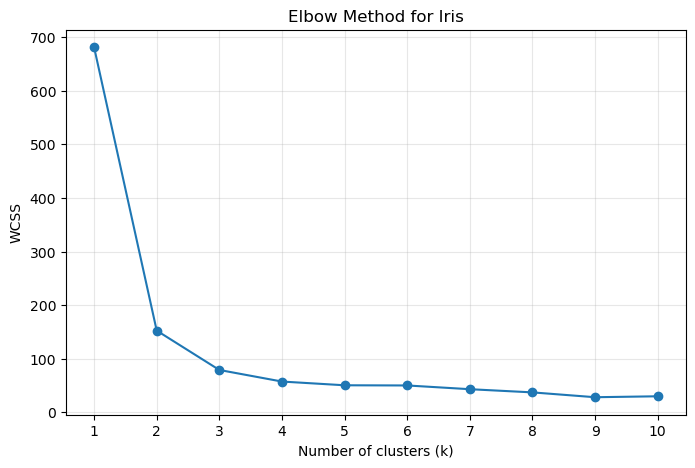

In [11]:
# Elbow method
k_values = range(1, 11)
wcss = []

for k in k_values:
    model = KMeans(n_clusters=k, max_iter=100)
    labels = model.fit_predict(X_iris)
    distances = np.linalg.norm(X_iris - model.centroids[labels], axis=1)
    wcss.append(np.sum(distances ** 2))

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Iris')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)
plt.show()

##### SKlearn implentation

Confusion matrix:
[[ 0 50  0]
 [48  0  2]
 [14  0 36]]
Aligned accuracy(sklearn): 0.8933333333333333


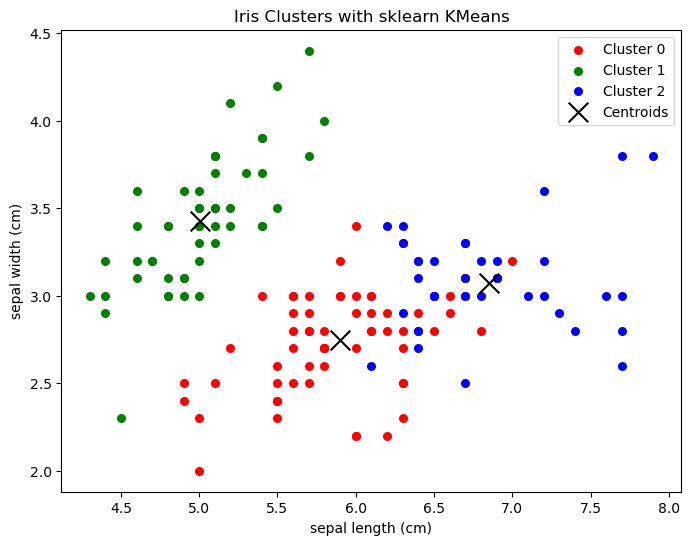

In [12]:
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment
from threadpoolctl import threadpool_limits

sk_kmeans = SklearnKMeans(n_clusters=3, random_state=42, n_init=10)
with threadpool_limits(limits=1, user_api="openmp"):
    sk_labels = sk_kmeans.fit_predict(X_iris)

cm = confusion_matrix(y_true, sk_labels)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
sk_aligned = np.array([mapping[label] for label in sk_labels])

print("Confusion matrix:")
print(cm)
print("Aligned accuracy(sklearn):", accuracy_score(y_true, sk_aligned))

plt.figure(figsize=(8, 6))
colors = ["red", "green", "blue"]

for cluster_idx in range(3):
    mask = sk_labels == cluster_idx
    plt.scatter(X_iris[mask, 0], X_iris[mask, 1], s=30, color=colors[cluster_idx], label=f"Cluster {cluster_idx}")

plt.scatter(sk_kmeans.cluster_centers_[:, 0], sk_kmeans.cluster_centers_[:, 1], s=200, color="black", marker="x", label="Centroids")
plt.xlabel(data.feature_names[0])
plt.ylabel(data.feature_names[1])
plt.title("Iris Clusters with sklearn KMeans")
plt.legend()
plt.show()